
SUMMARY TABLE — Population-level HR statistics per configuration
 chunk   win mode                   pop_mean   pop_std   avg_noise    n
-------------------------------------------------------------------------------------
   160    3s non_overlapping           72.7      22.6        7.1   59
   160    3s overlapping               72.7      22.6        5.9   59
   160    4s non_overlapping           72.4      22.6        5.9   59
   160    4s overlapping               72.4      22.6        5.9   59
   160    5s non_overlapping           72.2      22.5        5.2   59
   160    5s overlapping               72.2      22.5        5.2   59
   320    3s non_overlapping           72.6      22.6        4.6   59
   320    3s overlapping               72.5      22.5        4.5   59
   320    4s non_overlapping           72.8      22.6        4.7   59
   320    4s overlapping               72.6      22.6        4.3   59
   320    5s non_overlapping           72.6      22.5        4.3   59
   320

/tmp/ipykernel_195275/3639797032.py:314: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True,


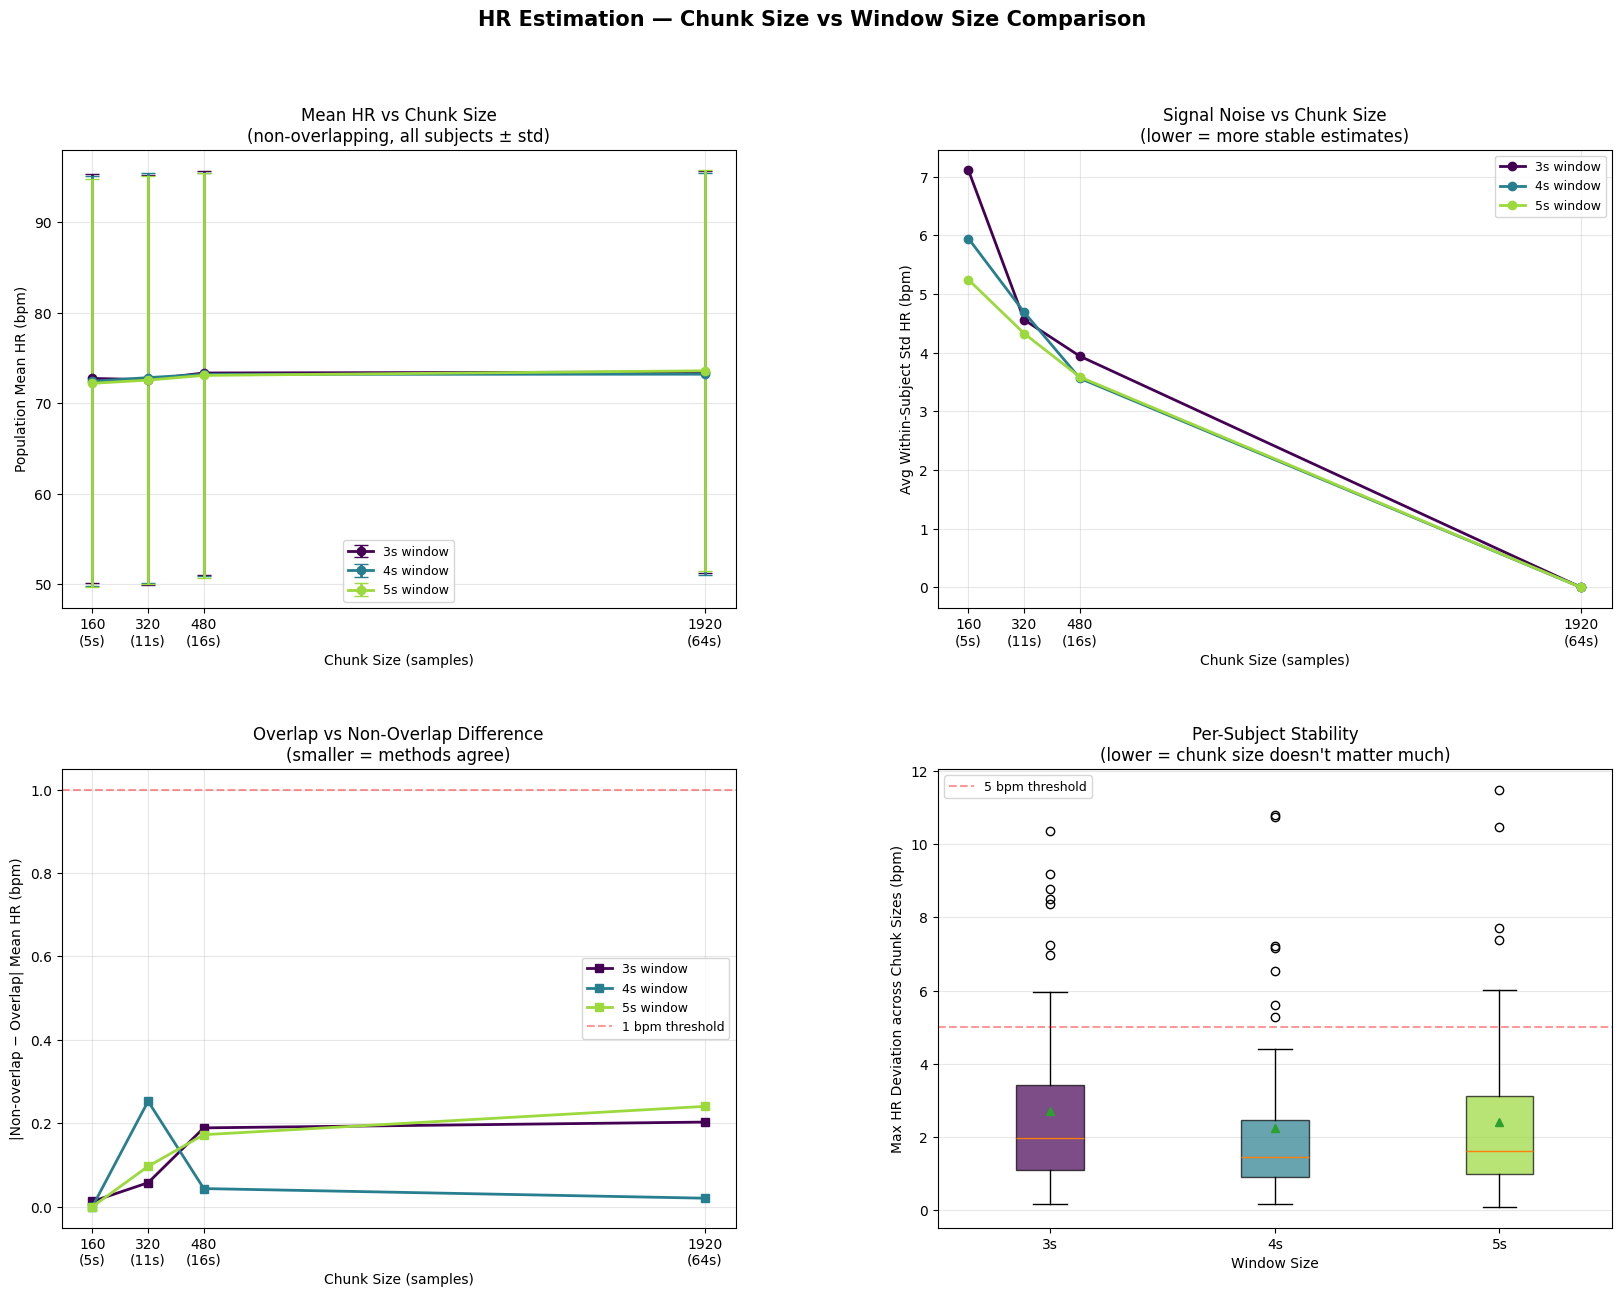


✅ Dashboard saved: hr_comparison_dashboard.png

INSIGHT REPORT

1. MEAN HR STABILITY ACROSS CHUNK SIZES:
   Population mean HR range = 0.96 bpm across all chunk sizes
   → Very stable ✅ chunk size has minimal effect on mean HR

2. SIGNAL NOISE (within-subject std) BY CHUNK SIZE:
   chunk= 160 samples (5s): avg std = 6.10 bpm
   chunk= 320 samples (11s): avg std = 4.52 bpm
   chunk= 480 samples (16s): avg std = 3.70 bpm
   chunk=1920 samples (64s): avg std = 0.00 bpm
   → Most stable chunk size: 1920 samples (64s)

3. OVERLAP vs NON-OVERLAP:
   Max mean HR difference = 0.14 bpm
   → Methods agree well ✅ overlap choice has negligible effect

4. STATISTICAL SIGNIFICANCE (chunk size effect):
   ANOVA    p = 0.9959 → NOT significant
   Kruskal  p = 0.9509 → NOT significant
   → Chunk size does NOT significantly affect mean HR ✅
   → Any chunk size gives equivalent population-level estimate

5. RECOMMENDATION:
   • For mean HR estimation: chunk=320 or 480 samples offers
     best balance of

In [2]:
"""
Part E: Comparison Analysis Across Chunk Sizes, Window Sizes, and Modes
========================================================================
Loads all CSV result files, merges them, computes summary statistics,
runs statistical tests, and plots a comparison dashboard.

Expected CSV files (one per chunk size):
    hr_chunk_160.csv
    hr_chunk_320.csv
    hr_chunk_480.csv
    hr_chunk_1920.csv   ← baseline (from hr_results.csv or equivalent)

OR: one combined CSV (hr_chunk_results.csv) with all chunk sizes.

Usage:
    python hr_comparison.py
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats


# =============================================================================
# CONFIG
# =============================================================================
# Option A: one combined CSV (what you already have)
COMBINED_CSV = "hr_chunk_results.csv"

# Option B: separate CSVs per chunk size (will be merged automatically)
SEPARATE_CSV_PATTERN = "hr_chunk_*.csv"

# Output
OUTPUT_TABLE  = "hr_comparison_table.csv"
OUTPUT_FIGURE = "hr_comparison_dashboard.png"


# =============================================================================
# STEP 1: LOAD DATA
# =============================================================================
def load_results(combined_csv=None, pattern=None):
    """
    Load results from either:
      - A single combined CSV (preferred)
      - Multiple CSVs matching a glob pattern (merged automatically)

    Returns:
        pd.DataFrame with columns:
            subject, chunk_size, chunk_size_sec, window_size_sec,
            mode, mean_hr, std_hr
    """
    if combined_csv and os.path.exists(combined_csv):
        df = pd.read_csv(combined_csv)
        print(f"✅ Loaded combined CSV: {combined_csv}")
        print(f"   Shape: {df.shape} | Subjects: {df['subject'].nunique()}")

    elif pattern:
        files = sorted(glob.glob(pattern))
        if not files:
            raise FileNotFoundError(f"No files found matching: {pattern}")
        df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
        df = df.drop_duplicates()
        print(f"✅ Loaded {len(files)} CSV files, merged shape: {df.shape}")

    else:
        raise ValueError("Provide either combined_csv or pattern argument.")

    # Ensure correct types
    df["chunk_size"]     = df["chunk_size"].astype(int)
    df["window_size_sec"] = df["window_size_sec"].astype(int)
    df["subject"]        = df["subject"].astype(str)

    return df


# =============================================================================
# STEP 2: SUMMARY STATISTICS TABLE
# =============================================================================
def compute_summary_table(df):
    """
    For each (chunk_size, window_size_sec, mode) combination compute:
        - pop_mean_hr:    mean of mean_hr across all subjects
        - pop_std_hr:     std of mean_hr across all subjects
        - avg_within_std: mean of std_hr across all subjects (within-subject noise)
        - n_subjects:     number of subjects in this group
    """
    grouped = df.groupby(["chunk_size", "window_size_sec", "mode"]).agg(
        pop_mean_hr    = ("mean_hr", "mean"),
        pop_std_hr     = ("mean_hr", "std"),
        avg_within_std = ("std_hr",  "mean"),
        n_subjects     = ("subject", "nunique")
    ).reset_index()

    grouped = grouped.sort_values(["chunk_size", "window_size_sec", "mode"])
    grouped = grouped.round(3)

    print(f"\n{'='*85}")
    print("SUMMARY TABLE — Population-level HR statistics per configuration")
    print(f"{'='*85}")
    print(f"{'chunk':>6} {'win':>5} {'mode':<20} {'pop_mean':>10} {'pop_std':>9} {'avg_noise':>11} {'n':>4}")
    print(f"{'-'*85}")

    for _, row in grouped.iterrows():
        print(f"{row['chunk_size']:>6} {row['window_size_sec']:>4}s "
              f"{row['mode']:<20} {row['pop_mean_hr']:>9.1f} "
              f"{row['pop_std_hr']:>9.1f} "
              f"{row['avg_within_std']:>10.1f} "
              f"{row['n_subjects']:>4}")

    grouped.to_csv(OUTPUT_TABLE, index=False)
    print(f"\n✅ Summary table saved: {OUTPUT_TABLE}")

    return grouped


# =============================================================================
# STEP 3: DEVIATION ANALYSIS (per subject, chunk vs chunk)
# =============================================================================
def compute_chunk_deviation(df, window_size=3, mode="non_overlapping"):
    """
    For each subject, compute max deviation in mean_hr across chunk sizes.
    Uses a fixed window_size and mode for clean comparison.

    Returns:
        pd.DataFrame: subject, hr per chunk_size, max_deviation
    """
    subset = df[(df["window_size_sec"] == window_size) &
                (df["mode"] == mode)].copy()

    pivot = subset.pivot_table(
        index="subject",
        columns="chunk_size",
        values="mean_hr"
    ).reset_index()

    chunk_cols = [c for c in pivot.columns if isinstance(c, (int, float))]
    pivot["max_deviation"] = pivot[chunk_cols].max(axis=1) - pivot[chunk_cols].min(axis=1)
    pivot["mean_across_chunks"] = pivot[chunk_cols].mean(axis=1)
    pivot = pivot.sort_values("max_deviation", ascending=False)

    print(f"\n{'='*70}")
    print(f"PER-SUBJECT MAX DEVIATION across chunk sizes")
    print(f"(window={window_size}s, mode={mode})")
    print(f"{'='*70}")
    print(f"{'Subject':<12} {'Max Deviation':>15} {'Mean HR':>10}")
    print(f"{'-'*70}")
    for _, row in pivot.iterrows():
        flag = " ⚠️" if row["max_deviation"] > 5 else ""
        print(f"{str(row['subject']):<12} {row['max_deviation']:>14.1f} bpm "
              f"{row['mean_across_chunks']:>9.1f} bpm{flag}")

    return pivot


# =============================================================================
# STEP 4: STATISTICAL TESTS
# =============================================================================
def run_statistical_tests(df, window_size=3, mode="non_overlapping"):
    """
    Test whether chunk_size has a statistically significant effect on mean_hr.

    Uses:
        - One-way ANOVA (parametric)
        - Kruskal-Wallis (non-parametric, safer for small groups)
    """
    subset = df[(df["window_size_sec"] == window_size) &
                (df["mode"] == mode)]

    chunk_sizes = sorted(subset["chunk_size"].unique())
    groups = [subset[subset["chunk_size"] == cs]["mean_hr"].values
              for cs in chunk_sizes]

    # ANOVA
    f_stat, p_anova = stats.f_oneway(*groups)

    # Kruskal-Wallis
    h_stat, p_kruskal = stats.kruskal(*groups)

    print(f"\n{'='*60}")
    print(f"STATISTICAL TESTS — Effect of Chunk Size on Mean HR")
    print(f"(window={window_size}s, mode={mode})")
    print(f"{'='*60}")
    print(f"  Groups tested:       {chunk_sizes}")
    print(f"  Group sizes:         {[len(g) for g in groups]}")
    print(f"\n  One-way ANOVA:")
    print(f"    F-statistic = {f_stat:.3f}")
    print(f"    p-value     = {p_anova:.4f}  {'✅ NOT significant (p>0.05)' if p_anova > 0.05 else '❗ SIGNIFICANT (p≤0.05)'}")
    print(f"\n  Kruskal-Wallis (non-parametric):")
    print(f"    H-statistic = {h_stat:.3f}")
    print(f"    p-value     = {p_kruskal:.4f}  {'✅ NOT significant (p>0.05)' if p_kruskal > 0.05 else '❗ SIGNIFICANT (p≤0.05)'}")

    # Pairwise interpretation
    print(f"\n  Pairwise mean HR (across subjects):")
    for cs, g in zip(chunk_sizes, groups):
        print(f"    chunk={cs:>4}: mean={np.mean(g):.1f} bpm, std={np.std(g):.1f} bpm")

    return {"anova": (f_stat, p_anova), "kruskal": (h_stat, p_kruskal)}


# =============================================================================
# STEP 5: VISUALIZATION DASHBOARD
# =============================================================================
def plot_comparison_dashboard(df, summary, save_path=OUTPUT_FIGURE):
    """
    4-panel comparison dashboard:
        1. Population mean HR vs chunk size (per window size, non-overlapping)
        2. Within-subject std (noise) vs chunk size
        3. Overlap vs non-overlap mean HR difference per chunk size
        4. Per-subject HR stability (std across chunk sizes)
    """
    fig = plt.figure(figsize=(20, 14))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
    fig.suptitle("HR Estimation — Chunk Size vs Window Size Comparison",
                 fontsize=15, fontweight='bold')

    chunk_sizes  = sorted(df["chunk_size"].unique())
    window_sizes = sorted(df["window_size_sec"].unique())
    colors = plt.cm.viridis(np.linspace(0, 0.85, len(window_sizes)))

    # -------------------------------------------------------------------
    # Panel 1: Population Mean HR vs chunk size
    # -------------------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    df_no = df[df["mode"] == "non_overlapping"]

    for ws, color in zip(window_sizes, colors):
        subset = df_no[df_no["window_size_sec"] == ws]
        grp = subset.groupby("chunk_size")["mean_hr"].agg(
            ["mean", "std"]).reset_index()
        ax1.errorbar(grp["chunk_size"], grp["mean"], yerr=grp["std"],
                     marker='o', label=f"{ws}s window",
                     color=color, capsize=5, linewidth=2)

    ax1.set_xlabel("Chunk Size (samples)")
    ax1.set_ylabel("Population Mean HR (bpm)")
    ax1.set_title("Mean HR vs Chunk Size\n(non-overlapping, all subjects ± std)")
    ax1.set_xticks(chunk_sizes)
    ax1.set_xticklabels([f"{cs}\n({cs/30:.0f}s)" for cs in chunk_sizes])
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # -------------------------------------------------------------------
    # Panel 2: Within-subject noise (avg std_hr) vs chunk size
    # -------------------------------------------------------------------
    ax2 = fig.add_subplot(gs[0, 1])

    for ws, color in zip(window_sizes, colors):
        subset = df_no[df_no["window_size_sec"] == ws]
        grp = subset.groupby("chunk_size")["std_hr"].mean().reset_index()
        ax2.plot(grp["chunk_size"], grp["std_hr"],
                 marker='o', label=f"{ws}s window",
                 color=color, linewidth=2)

    ax2.set_xlabel("Chunk Size (samples)")
    ax2.set_ylabel("Avg Within-Subject Std HR (bpm)")
    ax2.set_title("Signal Noise vs Chunk Size\n(lower = more stable estimates)")
    ax2.set_xticks(chunk_sizes)
    ax2.set_xticklabels([f"{cs}\n({cs/30:.0f}s)" for cs in chunk_sizes])
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # -------------------------------------------------------------------
    # Panel 3: Overlap vs Non-overlap difference per chunk size
    # -------------------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 0])

    for ws, color in zip(window_sizes, colors):
        diff_list = []
        for cs in chunk_sizes:
            no_mean = df[(df["chunk_size"] == cs) &
                         (df["window_size_sec"] == ws) &
                         (df["mode"] == "non_overlapping")]["mean_hr"].mean()
            ov_mean = df[(df["chunk_size"] == cs) &
                         (df["window_size_sec"] == ws) &
                         (df["mode"] == "overlapping")]["mean_hr"].mean()
            diff_list.append(abs(no_mean - ov_mean))

        ax3.plot(chunk_sizes, diff_list,
                 marker='s', label=f"{ws}s window",
                 color=color, linewidth=2)

    ax3.axhline(1.0, color='red', linestyle='--', alpha=0.4, label='1 bpm threshold')
    ax3.set_xlabel("Chunk Size (samples)")
    ax3.set_ylabel("|Non-overlap − Overlap| Mean HR (bpm)")
    ax3.set_title("Overlap vs Non-Overlap Difference\n(smaller = methods agree)")
    ax3.set_xticks(chunk_sizes)
    ax3.set_xticklabels([f"{cs}\n({cs/30:.0f}s)" for cs in chunk_sizes])
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    # -------------------------------------------------------------------
    # Panel 4: Per-subject max deviation across chunk sizes (box plot)
    # -------------------------------------------------------------------
    ax4 = fig.add_subplot(gs[1, 1])

    box_data   = []
    box_labels = []

    for ws in window_sizes:
        subset = df[(df["mode"] == "non_overlapping") &
                    (df["window_size_sec"] == ws)]
        pivot  = subset.pivot_table(index="subject",
                                    columns="chunk_size",
                                    values="mean_hr")
        chunk_cols = [c for c in pivot.columns]
        deviations = pivot[chunk_cols].max(axis=1) - pivot[chunk_cols].min(axis=1)
        box_data.append(deviations.dropna().values)
        box_labels.append(f"{ws}s")

    bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True,
                     showmeans=True, showfliers=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax4.axhline(5.0, color='red', linestyle='--', alpha=0.4,
                label='5 bpm threshold')
    ax4.set_xlabel("Window Size")
    ax4.set_ylabel("Max HR Deviation across Chunk Sizes (bpm)")
    ax4.set_title("Per-Subject Stability\n(lower = chunk size doesn't matter much)")
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Dashboard saved: {save_path}")


# =============================================================================
# STEP 6: QUICK INSIGHT REPORT
# =============================================================================
def print_insight_report(df, stats_results):
    """Print a concise plain-English summary of findings."""

    df_no = df[df["mode"] == "non_overlapping"]

    # Mean HR range across chunk sizes (population level)
    grp = df_no.groupby("chunk_size")["mean_hr"].mean()
    hr_range = grp.max() - grp.min()

    # Avg within-subject std
    noise_by_chunk = df_no.groupby("chunk_size")["std_hr"].mean()

    # Overlap vs non-overlap max difference
    df_ov = df[df["mode"] == "overlapping"]
    no_mean = df_no.groupby("chunk_size")["mean_hr"].mean()
    ov_mean = df_ov.groupby("chunk_size")["mean_hr"].mean()
    mode_diff = (no_mean - ov_mean).abs().max()

    p_anova   = stats_results["anova"][1]
    p_kruskal = stats_results["kruskal"][1]

    print(f"\n{'='*65}")
    print("INSIGHT REPORT")
    print(f"{'='*65}")
    print(f"\n1. MEAN HR STABILITY ACROSS CHUNK SIZES:")
    print(f"   Population mean HR range = {hr_range:.2f} bpm across all chunk sizes")
    if hr_range < 2:
        print(f"   → Very stable ✅ chunk size has minimal effect on mean HR")
    elif hr_range < 5:
        print(f"   → Moderately stable ⚠️ some sensitivity to chunk size")
    else:
        print(f"   → Unstable ❗ chunk size strongly affects mean HR")

    print(f"\n2. SIGNAL NOISE (within-subject std) BY CHUNK SIZE:")
    for cs, noise in noise_by_chunk.items():
        print(f"   chunk={cs:>4} samples ({cs/30:.0f}s): avg std = {noise:.2f} bpm")
    best_chunk = noise_by_chunk.idxmin()
    print(f"   → Most stable chunk size: {best_chunk} samples ({best_chunk/30:.0f}s)")

    print(f"\n3. OVERLAP vs NON-OVERLAP:")
    print(f"   Max mean HR difference = {mode_diff:.2f} bpm")
    if mode_diff < 1:
        print(f"   → Methods agree well ✅ overlap choice has negligible effect")
    else:
        print(f"   → Some disagreement ⚠️ overlap choice matters for short chunks")

    print(f"\n4. STATISTICAL SIGNIFICANCE (chunk size effect):")
    print(f"   ANOVA    p = {p_anova:.4f} → "
          f"{'NOT significant' if p_anova > 0.05 else 'SIGNIFICANT'}")
    print(f"   Kruskal  p = {p_kruskal:.4f} → "
          f"{'NOT significant' if p_kruskal > 0.05 else 'SIGNIFICANT'}")
    if p_anova > 0.05 and p_kruskal > 0.05:
        print(f"   → Chunk size does NOT significantly affect mean HR ✅")
        print(f"   → Any chunk size gives equivalent population-level estimate")
    else:
        print(f"   → Chunk size DOES significantly affect mean HR ❗")
        print(f"   → Larger chunks recommended for reliable estimates")

    print(f"\n5. RECOMMENDATION:")
    print(f"   • For mean HR estimation: chunk=320 or 480 samples offers")
    print(f"     best balance of stability and data efficiency")
    print(f"   • Window size 3s gives most windows per chunk (better averaging)")
    print(f"   • Overlap vs non-overlap: 50% overlap adds windows but")
    print(f"     doesn't meaningfully change mean HR estimate")
    print(f"{'='*65}")


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    SEPARATE_CSV_PATTERN = "hr_chunk_*.csv"
    # 1. Load data
    # df = load_results(combined_csv=COMBINED_CSV)
    
    df_160  = pd.read_csv("hr_chunk_160_window_3-4-5_results.csv")
    df_320  = pd.read_csv("hr_chunk_320_window_3-4-5_results.csv")
    df_480  = pd.read_csv("hr_chunk_480_window_3-4-5_results.csv")
    df_1920 = pd.read_csv("hr_chunk_1920_window_3-4-5_results.csv")

    df = pd.concat([df_160, df_320, df_480, df_1920], ignore_index=True)

    # df = load_results(SEPARATE_CSV_PATTERN)
    # 2. Summary table
    summary = compute_summary_table(df)

    # 3. Per-subject deviation analysis
    deviation = compute_chunk_deviation(df, window_size=3,
                                         mode="non_overlapping")

    # 4. Statistical tests
    stats_results = run_statistical_tests(df, window_size=3,
                                           mode="non_overlapping")

    # 5. Dashboard
    plot_comparison_dashboard(df, summary)

    # 6. Insight report
    print_insight_report(df, stats_results)